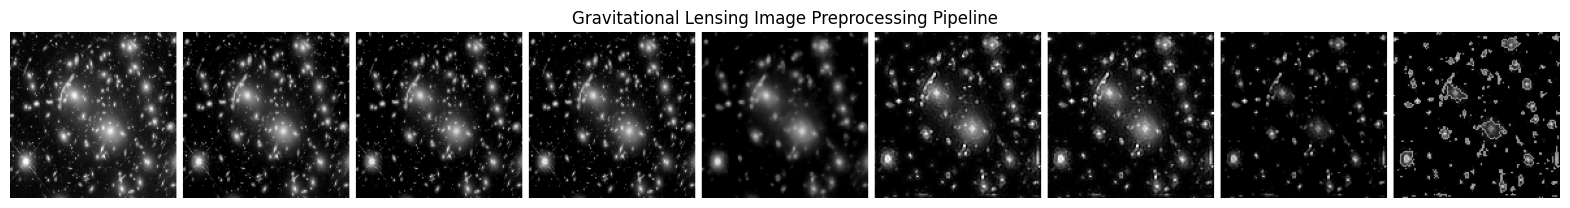

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import fftconvolve

# ---- Helper: Wiener Deconvolution ----
def wiener_deconvolution(image, psf, balance=0.01):
    psf_mirror = psf[::-1, ::-1]
    image_fft = np.fft.fft2(image)
    psf_fft = np.fft.fft2(psf, s=image.shape)
    psf_fft_conj = np.conj(psf_fft)
    wiener_filter = psf_fft_conj / (psf_fft * psf_fft_conj + balance)
    result_fft = image_fft * wiener_filter
    result = np.abs(np.fft.ifft2(result_fft))
    return result

# ---- Step 0: Load and Resize Image ----
img = cv2.imread('abc.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128, 128))
processed_images = [img]

# ---- Step 1: Bias Correction ----
bias = 15
img = cv2.subtract(img, bias)
processed_images.append(img)

# ---- Step 2: Dark Frame Subtraction ----
dark_frame = np.random.normal(10, 2, img.shape).astype(np.uint8)
img = cv2.subtract(img, dark_frame)
processed_images.append(img)

# ---- Step 3: Flat-Field Correction ----
flat_field = cv2.GaussianBlur(np.ones_like(img, dtype=np.float32) * 255, (51, 51), 0)
flat_norm = flat_field / np.max(flat_field)
img = (img / flat_norm).clip(0, 255).astype(np.uint8)
processed_images.append(img)

# ---- Step 4: Cosmic Ray Removal ----
img = cv2.medianBlur(img, 3)
processed_images.append(img)

# ---- Step 5: PSF Correction (Wiener Deconvolution) ----
psf = cv2.getGaussianKernel(5, 1).dot(cv2.getGaussianKernel(5, 1).T)
img = wiener_deconvolution(img, psf).clip(0, 255).astype(np.uint8)
processed_images.append(img)

# ---- Step 6: Image Stacking (Simulated with Noise) ----
noisy_imgs = [img + np.random.normal(0, 5, img.shape) for _ in range(3)]
img = np.mean(noisy_imgs, axis=0).clip(0, 255).astype(np.uint8)
processed_images.append(img)

# ---- Step 7: Background Subtraction ----
background = cv2.GaussianBlur(img, (51, 51), 0)
img = cv2.subtract(img, background)
processed_images.append(img)

# ---- Step 8: Source Detection & Deblending ----
_, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_detected = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_detected, contours, -1, (0, 255, 0), 1)
img = cv2.cvtColor(img_detected, cv2.COLOR_BGR2GRAY)
processed_images.append(img)

# ---- Combine All Images with Gaps ----
gap = 5
total_width = 128 * len(processed_images) + gap * (len(processed_images) - 1)
combined = np.ones((128, total_width), dtype=np.uint8) * 255  # white background

x = 0
for p in processed_images:
    combined[:, x:x+128] = p
    x += 128 + gap

# ---- Display Result ----
plt.figure(figsize=(20, 3))
plt.imshow(combined, cmap='gray')
plt.axis('off')
plt.title('Gravitational Lensing Image Preprocessing Pipeline')
plt.show()

Estimated lens center: (72, 49)


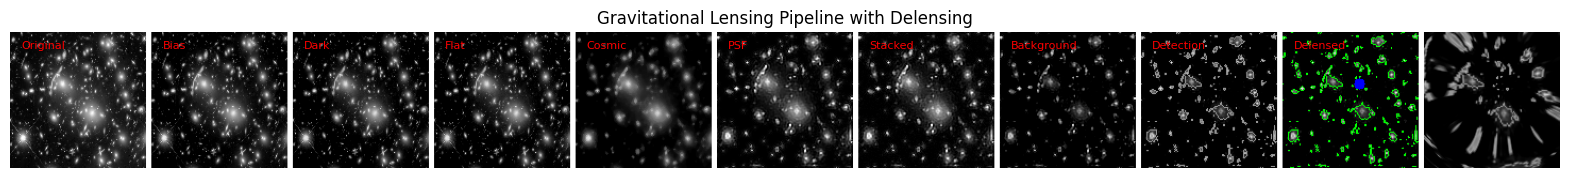

In [ ]:
# ---- Lens Physics Extension ----
def estimate_lens_center(contours, img_shape):
    """Estimate lens center using contour symmetry"""
    moments = []
    for cnt in contours:
        if cv2.contourArea(cnt) > 10:
            M = cv2.moments(cnt)
            if M['m00'] > 0:
                cx = M['m10']/M['m00']
                cy = M['m01']/M['m00']
                moments.append((cx, cy))

    # Use geometric median of contour centroids
    points = np.array(moments)
    center = np.median(points, axis=0)
    return (int(center[0]), int(center[1]))

def delens_image(image, center, strength=0.5):
    """Simple radial distortion correction"""
    h, w = image.shape
    y, x = np.indices((h, w))

    # Convert to polar coordinates relative to lens center
    x_norm = (x - center[0]) / (0.5*w)
    y_norm = (y - center[1]) / (0.5*h)
    r = np.sqrt(x_norm**2 + y_norm**2)
    theta = np.arctan2(y_norm, x_norm)

    # Apply inverse radial distortion
    r_corrected = r * (1 - strength*r**2)  # Simple inverse lens model
    x_corr = r_corrected * np.cos(theta) * (0.5*w) + center[0]
    y_corr = r_corrected * np.sin(theta) * (0.5*h) + center[1]

    # Remap image
    map_x = x_corr.astype(np.float32)
    map_y = y_corr.astype(np.float32)
    delensed = cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR)
    return delensed

# ---- Modified Processing Pipeline ----
# ... (previous steps until Step 8) ...

# Step 8: Source Detection & Lens Center Estimation
_, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Estimate lens center
lens_center = estimate_lens_center(contours, img.shape)
print(f"Estimated lens center: {lens_center}")

# Step 9: Delensing
img_delensed = delens_image(img, lens_center, strength=0.4)

# Visualization
img_detected = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_detected, contours, -1, (0, 255, 0), 1)
cv2.circle(img_detected, lens_center, 5, (0, 0, 255), -1)  # Mark lens center

# Update processed images
processed_images.append(img_detected)
processed_images.append(img_delensed)

# ---- Modified Combination ----
# Update combination code to handle color images
gap = 5
total_width = 128 * len(processed_images) + gap * (len(processed_images)-1)
combined = np.ones((128, total_width, 3), dtype=np.uint8) * 255  # RGB white

x = 0
for p in processed_images:
    # Convert grayscale to RGB if needed
    if p.ndim == 2:
        p_display = cv2.cvtColor(p, cv2.COLOR_GRAY2RGB)
    else:
        p_display = p

    resized = cv2.resize(p_display, (128, 128))
    combined[:, x:x+128] = resized
    x += 128 + gap

# Add step labels
labels = ['Original', 'Bias', 'Dark', 'Flat', 'Cosmic',
          'PSF', 'Stacked', 'Background', 'Detection', 'Delensed']
plt.figure(figsize=(20, 3))
plt.imshow(combined)
for i, label in enumerate(labels):
    plt.text(i*(128+gap)+10, 15, label, color='red', fontsize=8)
plt.axis('off')
plt.title('Gravitational Lensing Pipeline with Delensing')
plt.show()

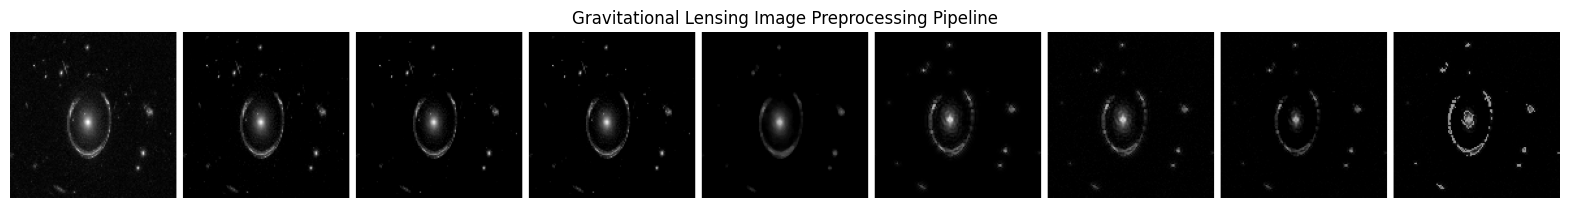

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import fftconvolve

# ---- Helper: Wiener Deconvolution ----
def wiener_deconvolution(image, psf, balance=0.01):
    psf_mirror = psf[::-1, ::-1]
    image_fft = np.fft.fft2(image)
    psf_fft = np.fft.fft2(psf, s=image.shape)
    psf_fft_conj = np.conj(psf_fft)
    wiener_filter = psf_fft_conj / (psf_fft * psf_fft_conj + balance)
    result_fft = image_fft * wiener_filter
    result = np.abs(np.fft.ifft2(result_fft))
    return result

# ---- Step 0: Load and Resize Image ----
img = cv2.imread('def.jpeg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128, 128))
processed_images = [img]

# ---- Step 1: Bias Correction ----
bias = 15
img = cv2.subtract(img, bias)
processed_images.append(img)

# ---- Step 2: Dark Frame Subtraction ----
dark_frame = np.random.normal(10, 2, img.shape).astype(np.uint8)
img = cv2.subtract(img, dark_frame)
processed_images.append(img)

# ---- Step 3: Flat-Field Correction ----
flat_field = cv2.GaussianBlur(np.ones_like(img, dtype=np.float32) * 255, (51, 51), 0)
flat_norm = flat_field / np.max(flat_field)
img = (img / flat_norm).clip(0, 255).astype(np.uint8)
processed_images.append(img)

# ---- Step 4: Cosmic Ray Removal ----
img = cv2.medianBlur(img, 3)
processed_images.append(img)

# ---- Step 5: PSF Correction (Wiener Deconvolution) ----
psf = cv2.getGaussianKernel(5, 1).dot(cv2.getGaussianKernel(5, 1).T)
img = wiener_deconvolution(img, psf).clip(0, 255).astype(np.uint8)
processed_images.append(img)

# ---- Step 6: Image Stacking (Simulated with Noise) ----
noisy_imgs = [img + np.random.normal(0, 5, img.shape) for _ in range(3)]
img = np.mean(noisy_imgs, axis=0).clip(0, 255).astype(np.uint8)
processed_images.append(img)

# ---- Step 7: Background Subtraction ----
background = cv2.GaussianBlur(img, (51, 51), 0)
img = cv2.subtract(img, background)
processed_images.append(img)

# ---- Step 8: Source Detection & Deblending ----
_, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_detected = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_detected, contours, -1, (0, 255, 0), 1)
img = cv2.cvtColor(img_detected, cv2.COLOR_BGR2GRAY)
processed_images.append(img)

# ---- Combine All Images with Gaps ----
gap = 5
total_width = 128 * len(processed_images) + gap * (len(processed_images) - 1)
combined = np.ones((128, total_width), dtype=np.uint8) * 255  # white background

x = 0
for p in processed_images:
    combined[:, x:x+128] = p
    x += 128 + gap

# ---- Display Result ----
plt.figure(figsize=(20, 3))
plt.imshow(combined, cmap='gray')
plt.axis('off')
plt.title('Gravitational Lensing Image Preprocessing Pipeline')
plt.show()

Estimated lens center: (60, 61)


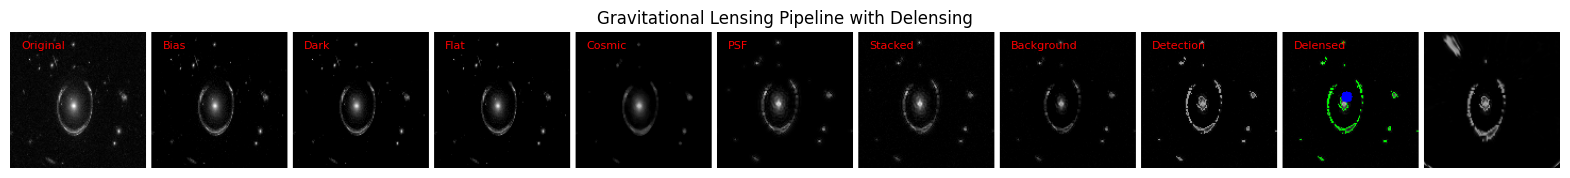

In [ ]:
# ---- Lens Physics Extension ----
def estimate_lens_center(contours, img_shape):
    """Estimate lens center using contour symmetry"""
    moments = []
    for cnt in contours:
        if cv2.contourArea(cnt) > 10:
            M = cv2.moments(cnt)
            if M['m00'] > 0:
                cx = M['m10']/M['m00']
                cy = M['m01']/M['m00']
                moments.append((cx, cy))

    # Use geometric median of contour centroids
    points = np.array(moments)
    center = np.median(points, axis=0)
    return (int(center[0]), int(center[1]))

def delens_image(image, center, strength=0.5):
    """Simple radial distortion correction"""
    h, w = image.shape
    y, x = np.indices((h, w))

    # Convert to polar coordinates relative to lens center
    x_norm = (x - center[0]) / (0.5*w)
    y_norm = (y - center[1]) / (0.5*h)
    r = np.sqrt(x_norm**2 + y_norm**2)
    theta = np.arctan2(y_norm, x_norm)

    # Apply inverse radial distortion
    r_corrected = r * (1 - strength*r**2)  # Simple inverse lens model
    x_corr = r_corrected * np.cos(theta) * (0.5*w) + center[0]
    y_corr = r_corrected * np.sin(theta) * (0.5*h) + center[1]

    # Remap image
    map_x = x_corr.astype(np.float32)
    map_y = y_corr.astype(np.float32)
    delensed = cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR)
    return delensed

# ---- Modified Processing Pipeline ----
# ... (previous steps until Step 8) ...

# Step 8: Source Detection & Lens Center Estimation
_, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Estimate lens center
lens_center = estimate_lens_center(contours, img.shape)
print(f"Estimated lens center: {lens_center}")

# Step 9: Delensing
img_delensed = delens_image(img, lens_center, strength=0.4)

# Visualization
img_detected = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_detected, contours, -1, (0, 255, 0), 1)
cv2.circle(img_detected, lens_center, 5, (0, 0, 255), -1)  # Mark lens center

# Update processed images
processed_images.append(img_detected)
processed_images.append(img_delensed)

# ---- Modified Combination ----
# Update combination code to handle color images
gap = 5
total_width = 128 * len(processed_images) + gap * (len(processed_images)-1)
combined = np.ones((128, total_width, 3), dtype=np.uint8) * 255  # RGB white

x = 0
for p in processed_images:
    # Convert grayscale to RGB if needed
    if p.ndim == 2:
        p_display = cv2.cvtColor(p, cv2.COLOR_GRAY2RGB)
    else:
        p_display = p

    resized = cv2.resize(p_display, (128, 128))
    combined[:, x:x+128] = resized
    x += 128 + gap

# Add step labels
labels = ['Original', 'Bias', 'Dark', 'Flat', 'Cosmic',
          'PSF', 'Stacked', 'Background', 'Detection', 'Delensed']
plt.figure(figsize=(20, 3))
plt.imshow(combined)
for i, label in enumerate(labels):
    plt.text(i*(128+gap)+10, 15, label, color='red', fontsize=8)
plt.axis('off')
plt.title('Gravitational Lensing Pipeline with Delensing')
plt.show()